In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("--- LOADING DATA FOR NETWORK ANALYSIS ---")
df = pd.read_csv('senate_processed_data_with_alpha.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(f"Graph pipeline ready. Transactions: {len(df)}")

--- LOADING DATA FOR NETWORK ANALYSIS ---
Graph pipeline ready. Transactions: 4699



--- STEP 7: TRANSACTION NETWORK VISUALIZATION ---


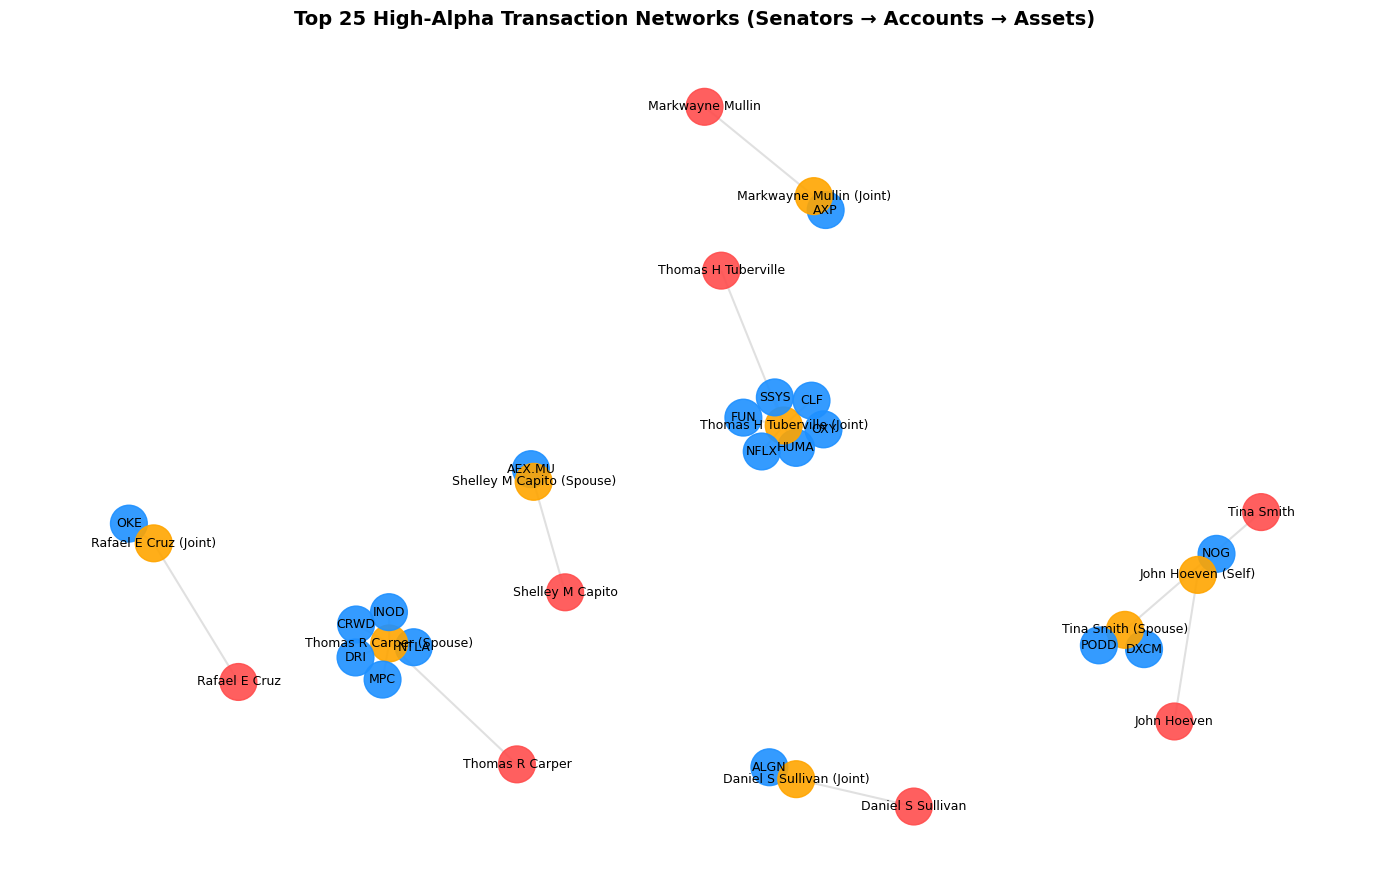

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n--- STEP 7: TRANSACTION NETWORK VISUALIZATION ---")

G = nx.Graph()

# Drop rows where alpha computation is missing
df_net = df.dropna(subset=['alpha']).copy()

# Dynamic check for account type or owner column mapping
account_col = None
if 'account_type' in df_net.columns:
    account_col = 'account_type'
elif 'owner' in df_net.columns:
    account_col = 'owner'

# Select top 25 transactions with the highest absolute alpha variations
top_suspicious = df_net.loc[df_net['alpha'].abs().sort_values(ascending=False).index].head(25)

for _, record in top_suspicious.iterrows():
    senator_node = f"{record['first_name']} {record['last_name']}"
    asset_node   = str(record['ticker']).strip()
    
    # Fallback to 'Standard' if ownership column is missing from the data schema
    acc_type = record[account_col] if account_col else "Standard"
    account_node = f"{senator_node} ({acc_type})"
    
    # Add network entities
    G.add_node(senator_node, entity_type='Senator')
    G.add_node(asset_node, entity_type='Asset')
    G.add_node(account_node, entity_type='AccountType')
    
    # Connect edges
    G.add_edge(senator_node, account_node)
    
    # Map edge weight directly to the absolute magnitude of market alpha
    edge_weight = abs(float(record['alpha']))
    G.add_edge(account_node, asset_node, weight=edge_weight)

# Visualization setup
plt.figure(figsize=(14, 9))
layout = nx.spring_layout(G, k=0.4, seed=101)

# Color mapping logic by node classification
color_map = []
for node, attrs in G.nodes(data=True):
    if attrs.get('entity_type') == 'Senator':
        color_map.append('#ff4d4d')  # Red for political actors
    elif attrs.get('entity_type') == 'Asset':
        color_map.append('#1e90ff')  # Blue for financial instruments
    else:
        color_map.append('#ffa500')  # Orange for structural account proxies

# Render pipeline
nx.draw_networkx_nodes(G, layout, node_color=color_map, node_size=700, alpha=0.9)
nx.draw_networkx_edges(G, layout, width=1.5, edge_color='#cccccc', alpha=0.6)
nx.draw_networkx_labels(G, layout, font_size=9, font_family='sans-serif')

plt.title("Top 25 High-Alpha Transaction Networks (Senators → Accounts → Assets)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


--- STEP 8: MARKET TIMING DETECTION ---


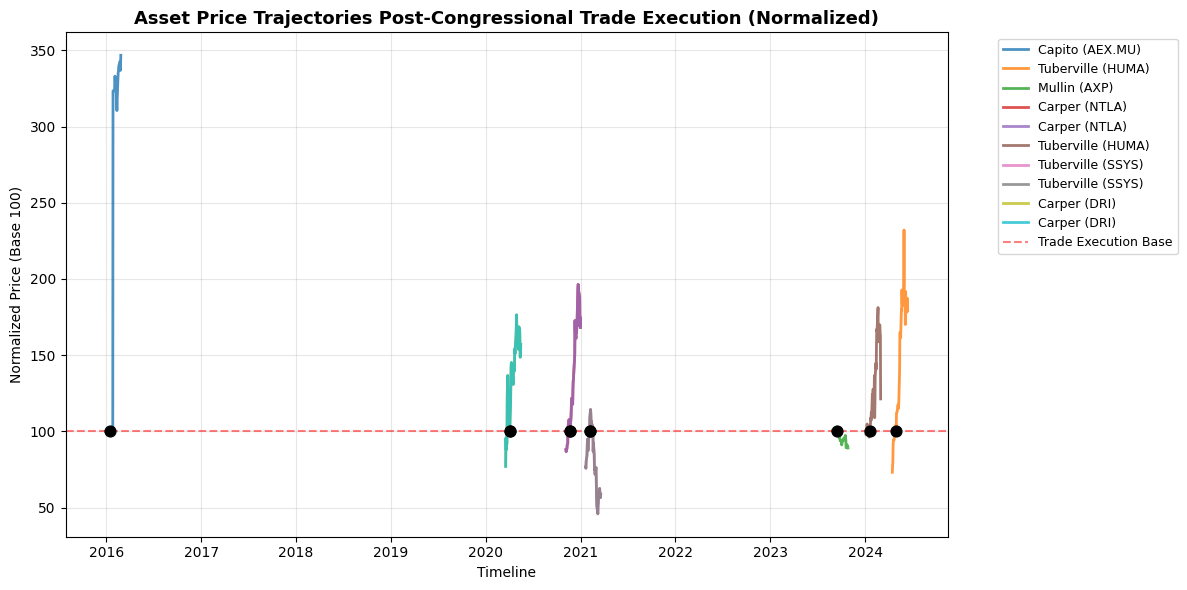

In [7]:
from datetime import timedelta
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n--- STEP 8: MARKET TIMING DETECTION ---")

# Ensure target dataframe has valid alpha values
df_timing = df.dropna(subset=['alpha']).copy()

# Sort by highest absolute alpha to find the most impactful trades
significant_trades = df_timing.loc[df_timing['alpha'].abs().sort_values(ascending=False).index].head(10)

plt.figure(figsize=(12, 6))

for idx, row in significant_trades.iterrows():
    ticker     = str(row['ticker']).strip()
    trade_date = pd.to_datetime(row['transaction_date'])
    end_date   = trade_date + timedelta(days=45)
    
    try:
        stock = yf.download(ticker, start=trade_date - timedelta(days=15), end=end_date, progress=False)
        if not stock.empty:
            stock.index = stock.index.tz_localize(None).normalize()
            
            # Normalize price to 100 at transaction date for visual comparison
            close_series = stock['Close']
            if isinstance(close_series, pd.DataFrame):
                close_series = close_series.iloc[:, 0]
                
            closest_date = close_series.index[close_series.index >= trade_date][0]
            base_price = float(close_series.loc[closest_date])
            normalized_price = (close_series / base_price) * 100
            
            # Plot timeline around the trade execution
            label_name = f"{row['last_name']} ({ticker})"
            plt.plot(normalized_price.index, normalized_price, label=label_name, alpha=0.8, linewidth=2)
            plt.scatter(trade_date, 100, color='black', s=60, zorder=5)
    except Exception:
        continue

plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Trade Execution Base')
plt.title("Asset Price Trajectories Post-Congressional Trade Execution (Normalized)", fontsize=13, fontweight='bold')
plt.xlabel("Timeline", fontsize=10)
plt.ylabel("Normalized Price (Base 100)", fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Short-term round-trip trades (buy and sell the same asset within 30 days)
# are particularly informative: legitimate long-term investors rarely need
# to exit a position within one month. A rapid reversal suggests the senator
# entered the position to exploit a specific, time-limited informational
# advantage -- the classic "hit and run" insider trading signature.
#
# We detect these using a grouped shift operation: for each (senator, ticker)
# pair sorted chronologically, we compare each SELL to the immediately
# preceding BUY and compute the holding period in calendar days.
# =============================================================================

print("\n--- STEP 10: SHORT-TERM ROUND-TRIP (QUICK FLIP) DETECTION ---")

flip_df = df.copy()
flip_df = flip_df.sort_values(['last_name', 'first_name', 'ticker', 'transaction_date'])

flip_df['trade_type'] = flip_df['transaction'].astype(str).str.lower()
flip_df['is_buy']     = flip_df['trade_type'].str.contains('purchase|buy')
flip_df['is_sell']    = flip_df['trade_type'].str.contains('sale|sell')

# Shift within each (senator, ticker) group to access the immediately prior trade
grp_key = ['last_name', 'first_name', 'ticker']
flip_df['prev_is_buy'] = flip_df.groupby(grp_key)['is_buy'].shift(1)
flip_df['prev_date']   = flip_df.groupby(grp_key)['transaction_date'].shift(1)
flip_df['prev_volume'] = flip_df.groupby(grp_key)['estimated_volume'].shift(1)

# A quick flip is: current trade is SELL, previous trade for the same asset was BUY
quick_flips = flip_df[(flip_df['is_sell'] == True) & (flip_df['prev_is_buy'] == True)].copy()
quick_flips['holding_days'] = (quick_flips['transaction_date'] - quick_flips['prev_date']).dt.days

# Apply the 30-day threshold; holding_days > 0 excludes same-day recording artifacts
FLIP_WINDOW = 30
extreme_flips = quick_flips[
    (quick_flips['holding_days'] > 0) &
    (quick_flips['holding_days'] <= FLIP_WINDOW)
].copy()

if not extreme_flips.empty:
    extreme_flips['Senator']   = extreme_flips['first_name'] + ' ' + extreme_flips['last_name']
    extreme_flips['Buy_Date']  = extreme_flips['prev_date'].dt.strftime('%Y-%m-%d')
    extreme_flips['Sell_Date'] = extreme_flips['transaction_date'].dt.strftime('%Y-%m-%d')

    final_report = (extreme_flips[['Senator', 'ticker', 'Buy_Date', 'Sell_Date',
                                   'holding_days', 'prev_volume']]
                    .sort_values('holding_days'))
    final_report.columns = ['Senator', 'Asset', 'Bought_On', 'Sold_On',
                            'Days_Held', 'Investment_$']

    print(f"Identified {len(final_report)} round-trip trades completed within {FLIP_WINDOW} days:\n")
    print(final_report.to_string(index=False))
else:
    print(f"No Buy → Sell pairs within {FLIP_WINDOW} days found.")
    final_report = pd.DataFrame()


--- STEP 10: SHORT-TERM ROUND-TRIP (QUICK FLIP) DETECTION ---
Identified 77 round-trip trades completed within 30 days:

            Senator Asset  Bought_On    Sold_On  Days_Held  Investment_$
Thomas H Tuberville   CLF 2023-05-24 2023-05-25          1        8000.5
Thomas H Tuberville  PYPL 2022-11-07 2022-11-08          1      175000.5
Thomas H Tuberville  QCOM 2023-08-31 2023-09-01          1      175000.5
Thomas H Tuberville  TSLA 2023-04-03 2023-04-04          1        8000.5
Thomas H Tuberville  QCOM 2022-12-01 2022-12-02          1      175000.5
Thomas H Tuberville     X 2022-06-21 2022-06-22          1      175000.5
Thomas H Tuberville     X 2022-09-19 2022-09-20          1      175000.5
Thomas H Tuberville  PYPL 2022-12-08 2022-12-09          1       32500.5
Thomas H Tuberville   CVX 2024-04-29 2024-04-30          1        8000.5
Thomas H Tuberville  MSFT 2022-09-19 2022-09-20          1      375000.5
Thomas H Tuberville   HPQ 2023-10-30 2023-10-31          1       32500.5
Th

In [10]:
import pandas as pd
import yfinance as yf
import warnings
import logging

# Suppress noisy FutureWarnings from pandas and 404 errors from yfinance
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

print("\n--- STEP 11: PROFIT & LOSS CALCULATION FOR SHORT-TERM ROUND TRIPS ---")
print("Fetching actual historical prices to compute realized ROI...\n")

# Helper function to safely extract scalar values from yfinance returns
def get_scalar(val):
    if isinstance(val, pd.Series):
        return float(val.iloc[0])
    elif isinstance(val, pd.DataFrame):
        return float(val.iloc[0, 0])
    return float(val)

pl_results = []

# Ensure the final_report dataframe from the previous step exists
if 'final_report' in locals() and not final_report.empty:
    for _, row in final_report.iterrows():
        ticker   = row['Asset']
        buy_date = pd.to_datetime(row['Bought_On'])
        sel_date = pd.to_datetime(row['Sold_On'])
        volume   = float(row['Investment_$'])

        try:
            stock_data = yf.download(
                ticker,
                start=buy_date - pd.Timedelta(days=2),
                end=sel_date   + pd.Timedelta(days=4),
                progress=False
            )

            if not stock_data.empty and len(stock_data) >= 2:
                stock_data.index = stock_data.index.tz_localize(None).normalize()

                buy_rows = stock_data[stock_data.index >= buy_date]
                sel_rows = stock_data[stock_data.index >= sel_date]
                if buy_rows.empty or sel_rows.empty:
                    continue

                # Safely extract execution prices
                buy_price = get_scalar(buy_rows['Close'].iloc[0])
                sel_price = get_scalar(sel_rows['Close'].iloc[0])

                roi_pct    = ((sel_price - buy_price) / buy_price) * 100
                profit_usd = volume * (roi_pct / 100)

                pl_results.append({
                    'Senator'        : row['Senator'],
                    'Asset'          : ticker,
                    'Days_Held'      : row['Days_Held'],
                    'Volume_$'       : volume,
                    'ROI_%'          : round(roi_pct, 2),
                    'Profit_Loss_$'  : round(profit_usd, 2),
                })
        except Exception:
            continue

if pl_results:
    pl_df = pd.DataFrame(pl_results).sort_values('Profit_Loss_$', ascending=False)
    print("PROFIT & LOSS — SHORT-TERM ROUND TRIPS\n")
    print(pl_df.to_string(index=False))
    print(f"\nNet financial result across all quick flips : ${pl_df['Profit_Loss_$'].sum():,.2f}")
    print(f"Profitable flips : {(pl_df['ROI_%'] > 0).sum()} | Loss-making : {(pl_df['ROI_%'] < 0).sum()}")
else:
    print("Could not retrieve price data for P&L calculation.")


--- STEP 11: PROFIT & LOSS CALCULATION FOR SHORT-TERM ROUND TRIPS ---
Fetching actual historical prices to compute realized ROI...

PROFIT & LOSS — SHORT-TERM ROUND TRIPS

            Senator Asset  Days_Held  Volume_$  ROI_%  Profit_Loss_$
Thomas H Tuberville  QCOM         12  375000.5   8.92       33458.95
Thomas H Tuberville  INTC         13  175000.5   8.36       14625.74
John W Hickenlooper FWONK         12  375000.5   2.45        9180.21
Thomas H Tuberville  PYPL          1  175000.5   4.47        7819.34
Thomas H Tuberville   CLF         16   75000.5  10.24        7678.74
Thomas H Tuberville   CLF          8   32500.5  16.77        5450.68
Thomas H Tuberville   CLF          1   75000.5   6.48        4860.72
        Ron L Wyden  CRWD          3   32500.5   8.98        2917.03
Thomas H Tuberville  SSYS         21   32500.5   7.18        2333.37
Thomas H Tuberville     F          5  175000.5   1.15        2012.93
    Thomas R Carper   SQM         21    8000.5  18.35        1467.86


--- STEP 14: CO-INVESTMENT NETWORK ANALYSIS (PAGERANK) ---

[Top 10 Central Senators in Co-Investment Cartels - PageRank]
1. Shelley M Capito (Score: 0.1760)
2. Thomas H Tuberville (Score: 0.1387)
3. Daniel S Sullivan (Score: 0.1308)
4. Sheldon Whitehouse (Score: 0.1111)
5. Gary C Peters (Score: 0.1111)
6. Thomas R Carper (Score: 0.1111)
7. John Hoeven (Score: 0.1111)
8. Jerry Moran,   (Score: 0.0560)
9. Ron L Wyden (Score: 0.0541)


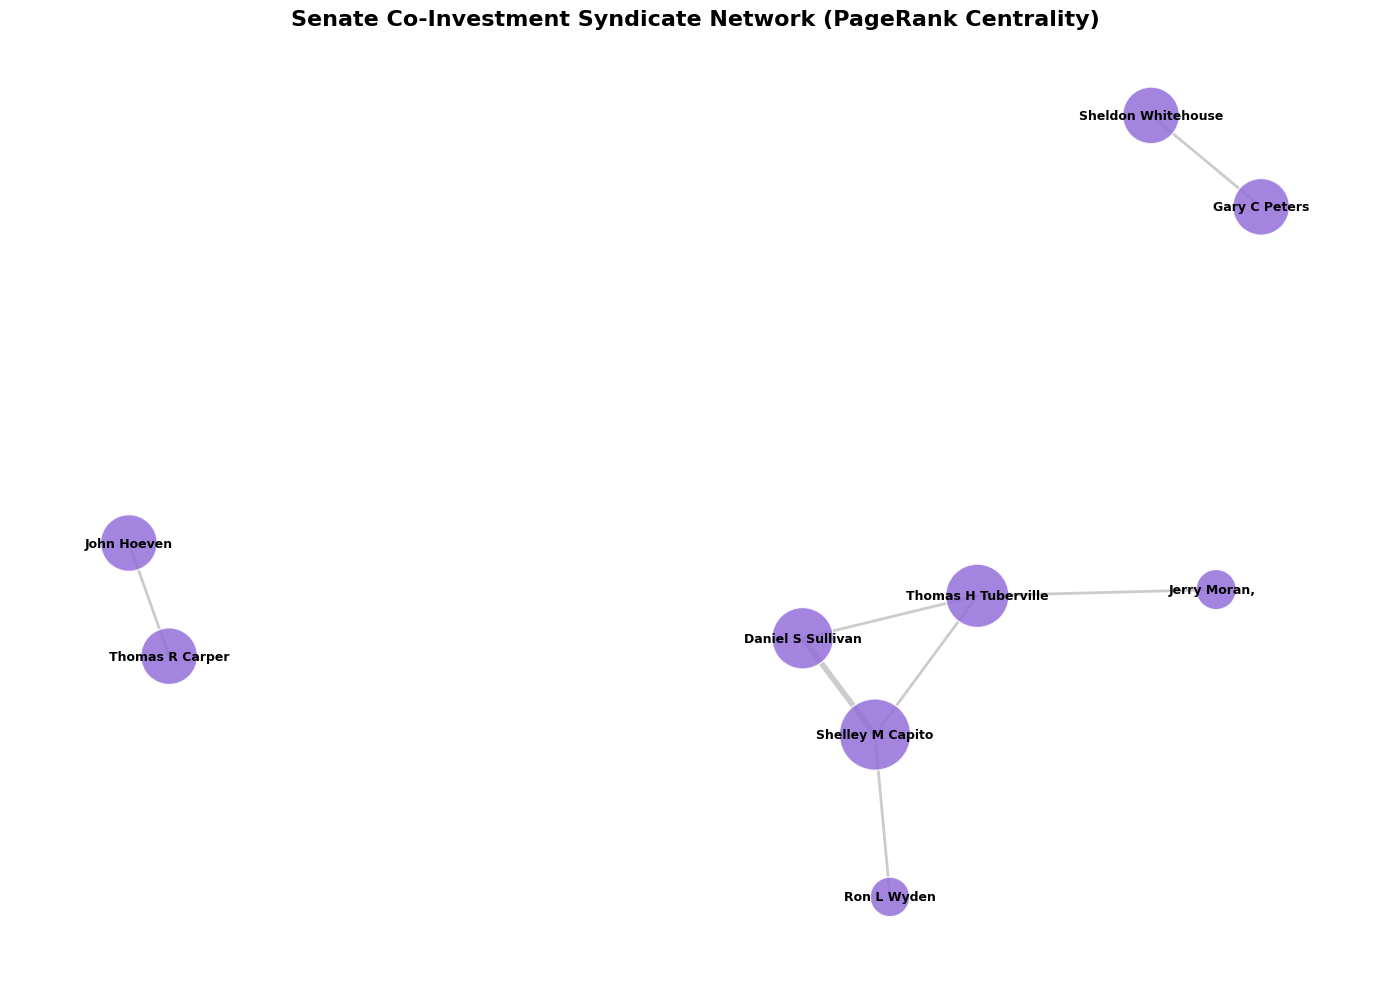

In [12]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

print("\n--- STEP 14: CO-INVESTMENT NETWORK ANALYSIS (PAGERANK) ---")

co_investments = []

# Grouping by transaction date and asset to find simultaneous trades
grouped = df.dropna(subset=['ticker', 'transaction_date']).groupby(['transaction_date', 'ticker'])

for (trade_date, ticker), group in grouped:
    senators_in_group = (
        group[['first_name', 'last_name']]
        .drop_duplicates()
        .apply(lambda r: f"{r['first_name']} {r['last_name']}", axis=1)
        .tolist()
    )
    # If more than one senator traded the exact same asset on the exact same day, create an edge
    if len(senators_in_group) > 1:
        for pair in combinations(senators_in_group, 2):
            co_investments.append({'source': pair[0], 'target': pair[1], 'ticker': ticker})

G_sync = nx.Graph()

# Build graph with edge weights representing the volume of co-investments
for edge in co_investments:
    if G_sync.has_edge(edge['source'], edge['target']):
        G_sync[edge['source']][edge['target']]['weight'] += 1
    else:
        G_sync.add_edge(edge['source'], edge['target'], weight=1)

if len(G_sync.nodes) == 0:
    print("No co-investments found in the dataset.")
else:
    # Calculate PageRank to find the most central figures in the network
    pagerank = nx.pagerank(G_sync, weight='weight')
    
    # Sort senators by PageRank centrality score
    top_central_senators = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
    
    print("\n[Top 10 Central Senators in Co-Investment Cartels - PageRank]")
    for rank, (senator, score) in enumerate(top_central_senators, 1):
        print(f"{rank}. {senator} (Score: {score:.4f})")

    # Network Visualization
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G_sync, k=0.6, seed=42)
    
    # Scale node size dynamically based on PageRank centrality
    node_sizes = [pagerank[node] * 15000 for node in G_sync.nodes()]
    
    # Scale edge thickness based on the number of co-investments
    edge_weights = [G_sync[u][v]['weight'] * 2 for u, v in G_sync.edges()]
    
    # Render network
    nx.draw_networkx_nodes(G_sync, pos, node_size=node_sizes, node_color='#9370db', alpha=0.85, edgecolors='white')
    nx.draw_networkx_edges(G_sync, pos, width=edge_weights, edge_color='#aaaaaa', alpha=0.6)
    nx.draw_networkx_labels(G_sync, pos, font_size=9, font_family='sans-serif', font_weight='bold')
    
    plt.title("Senate Co-Investment Syndicate Network (PageRank Centrality)", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [14]:
import pandas as pd

print("\n--- STEP 15: SYNDICATE ANALYSIS (COORDINATED TRADES) ---")

TOP_N_SENATORS = 5

# Using the PageRank results generated in the previous cell to identify the core group
if 'top_central_senators' in globals() and len(top_central_senators) >= 2:
    
    # Extract just the names from the PageRank tuple list
    top_senators = [item[0] for item in top_central_senators[:TOP_N_SENATORS]]
    print(f"Analyzing the {TOP_N_SENATORS} highest-centrality senators:\n  {', '.join(top_senators)}\n")

    def is_high_centrality(first_name, last_name):
        full_name = f"{first_name} {last_name}"
        # Loose matching to handle slight naming variations (e.g., suffixes)
        return any(
            ts.split()[0] in full_name and ts.split()[-1] in full_name
            for ts in top_senators
        )

    # Use the main dataframe, ensuring dates and weeks are set
    cartel_df = df.dropna(subset=['ticker', 'transaction_date', 'estimated_volume']).copy()
    cartel_df['trade_week'] = cartel_df['transaction_date'].dt.isocalendar().week
    cartel_df['trade_year'] = cartel_df['transaction_date'].dt.year
    
    # Filter for the core group members
    cartel_df['in_top_group'] = cartel_df.apply(
        lambda r: is_high_centrality(r['first_name'], r['last_name']), axis=1
    )
    cartel_df = cartel_df[cartel_df['in_top_group']].copy()
    
    # Standardize trade direction
    cartel_df['trade_type'] = cartel_df.apply(
        lambda r: 'BUY' if r.get('is_buy_order', 0) == 1 else 'SELL', axis=1
    )

    syndicate_moves = []

    # Group by Asset, Year, Week, and Trade Direction to find synchronized events
    for (ticker, year, week, trade_type), group in cartel_df.groupby(
        ['ticker', 'trade_year', 'trade_week', 'trade_type']
    ):
        unique_senators = group[['first_name', 'last_name']].drop_duplicates()
        
        # If more than 1 central senator made the exact same directional move in the same week
        if len(unique_senators) > 1:
            names = (
                unique_senators['first_name'] + ' ' + unique_senators['last_name']
            ).tolist()
            
            syndicate_moves.append({
                'Asset'              : ticker,
                'Year-Week'          : f"{year}-W{week}",
                'Action'             : trade_type,
                'Senators_Involved'  : ', '.join(names),
                'Count'              : len(names),
                'Total_Volume_$'     : group['estimated_volume'].sum(),
            })

    if syndicate_moves:
        syndicate_df = pd.DataFrame(syndicate_moves).sort_values(
            by=['Count', 'Total_Volume_$'], ascending=False
        )
        pd.set_option('display.max_colwidth', None)
        print("COORDINATED TRADES AMONG THE CENTRAL GROUP:\n")
        print(syndicate_df.head(20).to_string(index=False))
        pd.reset_option('display.max_colwidth')
    else:
        print("No coordinated same-direction trades found among the top-centrality group in the same week.")
        syndicate_df = pd.DataFrame()

else:
    print("Graph PageRank results not found. Please ensure STEP 14 ran successfully.")
    syndicate_df = pd.DataFrame()


--- STEP 15: SYNDICATE ANALYSIS (COORDINATED TRADES) ---
Analyzing the 5 highest-centrality senators:
  Shelley M Capito, Thomas H Tuberville, Daniel S Sullivan, Sheldon Whitehouse, Gary C Peters

COORDINATED TRADES AMONG THE CENTRAL GROUP:

Asset Year-Week Action                      Senators_Involved  Count  Total_Volume_$
 MSFT  2023-W25   SELL  Shelley M Capito, Thomas H Tuberville      2        383001.0
 MSFT  2023-W34   SELL    Daniel S Sullivan, Shelley M Capito      2        158001.5
 AAPL  2023-W34   SELL    Daniel S Sullivan, Shelley M Capito      2         73001.5
  MDT   2015-W5   SELL      Sheldon Whitehouse, Gary C Peters      2         48501.5
 MSFT  2022-W47    BUY Daniel S Sullivan, Thomas H Tuberville      2         32002.0
  BHF  2017-W34   SELL      Gary C Peters, Sheldon Whitehouse      2         16001.0


In [15]:
import yfinance as yf
import pandas as pd
import warnings
import logging
from datetime import timedelta

# Suppress noisy yfinance warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

print("\n--- STEP 16: 30-DAY POST-TRADE PERFORMANCE OF SYNDICATES ---")

def get_scalar(val):
    if isinstance(val, pd.Series):
        return float(val.iloc[0])
    elif isinstance(val, pd.DataFrame):
        return float(val.iloc[0, 0])
    return float(val)

performance_results = []

if 'syndicate_df' in globals() and not syndicate_df.empty:
    for _, row in syndicate_df.iterrows():
        ticker = row['Asset']
        year_week = row['Year-Week']
        action = row['Action']
        
        # Parse Year and Week to approximate the Monday of that trading week
        year, week = year_week.split('-W')
        trade_date = pd.to_datetime(f'{year}-W{week}-1', format='%G-W%V-%u')
        
        try:
            # Buffer data fetch to handle weekends and non-trading holidays
            stock_data = yf.download(
                ticker,
                start=trade_date,
                end=trade_date + timedelta(days=45),
                progress=False
            )
            
            if not stock_data.empty and len(stock_data) >= 2:
                stock_data.index = stock_data.index.tz_localize(None).normalize()
                
                entry_price = get_scalar(stock_data['Close'].iloc[0])
                
                target_date = trade_date + timedelta(days=30)
                exit_rows = stock_data[stock_data.index >= target_date]
                
                if not exit_rows.empty:
                    exit_price = get_scalar(exit_rows['Close'].iloc[0])
                else:
                    exit_price = get_scalar(stock_data['Close'].iloc[-1])
                    
                roi_pct = ((exit_price - entry_price) / entry_price) * 100
                
                # A WIN is when a BUY goes up, or a SELL goes down (loss avoidance)
                if (action == 'BUY' and roi_pct > 0) or (action == 'SELL' and roi_pct < 0):
                    outcome = "WIN (Insider Advantage)"
                else:
                    outcome = "LOSS (Missed Timing)"
                
                performance_results.append({
                    'Syndicate_Trade': f"{ticker} ({year_week})",
                    'Action': action,
                    'Senators': row['Senators_Involved'],
                    'Volume_$': row['Total_Volume_$'],
                    '30d_Asset_Return_%': round(roi_pct, 2),
                    'Syndicate_Success': outcome
                })
        except Exception:
            continue

    if performance_results:
        perf_df = pd.DataFrame(performance_results)
        pd.set_option('display.max_colwidth', None)
        print(perf_df.to_string(index=False))
        pd.reset_option('display.max_colwidth')
        
        wins = len(perf_df[perf_df['Syndicate_Success'] == 'WIN (Insider Advantage)'])
        total = len(perf_df)
        print(f"\n[FINAL METRIC] Syndicate Win Rate: {wins}/{total} ({(wins/total)*100:.1f}%)")
    else:
        print("Could not retrieve price data for syndicate performance.")
else:
    print("No syndicate trades to evaluate.")


--- STEP 16: 30-DAY POST-TRADE PERFORMANCE OF SYNDICATES ---
Syndicate_Trade Action                               Senators  Volume_$  30d_Asset_Return_%       Syndicate_Success
MSFT (2023-W25)   SELL  Shelley M Capito, Thomas H Tuberville  383001.0                5.04    LOSS (Missed Timing)
MSFT (2023-W34)   SELL    Daniel S Sullivan, Shelley M Capito  158001.5               -0.34 WIN (Insider Advantage)
AAPL (2023-W34)   SELL    Daniel S Sullivan, Shelley M Capito   73001.5               -0.20 WIN (Insider Advantage)
  MDT (2015-W5)   SELL      Sheldon Whitehouse, Gary C Peters   48501.5                4.02    LOSS (Missed Timing)
MSFT (2022-W47)    BUY Daniel S Sullivan, Thomas H Tuberville   32002.0                0.98 WIN (Insider Advantage)
 BHF (2017-W34)   SELL      Gary C Peters, Sheldon Whitehouse   16001.0                1.11    LOSS (Missed Timing)

[FINAL METRIC] Syndicate Win Rate: 3/6 (50.0%)


In [16]:
import yfinance as yf
import pandas as pd
import warnings
import logging

# Suppress noisy yfinance warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

print("\n--- STEP 17: 30-DAY AND 90-DAY ROI FOR COORDINATED TRADES ---")

def get_scalar(val):
    if isinstance(val, pd.Series):
        return float(val.iloc[0])
    elif isinstance(val, pd.DataFrame):
        return float(val.iloc[0, 0])
    return float(val)

pl_coord_results = []

if 'syndicate_df' in globals() and not syndicate_df.empty:
    for _, row in syndicate_df.iterrows():
        ticker     = row['Asset']
        year_week  = row['Year-Week']
        action     = row['Action']
        volume     = float(row['Total_Volume_$'])

        # Parse Year and Week to approximate the Monday of that trading week
        year, week = year_week.split('-W')
        trade_date = pd.to_datetime(f'{year}-W{week}-1', format='%G-W%V-%u')

        try:
            stock_data = yf.download(
                ticker,
                start=trade_date - pd.Timedelta(days=5),
                end=trade_date   + pd.Timedelta(days=95),
                progress=False
            )

            if not stock_data.empty and len(stock_data) >= 2:
                stock_data.index = stock_data.index.tz_localize(None).normalize()

                entry_rows = stock_data[stock_data.index >= trade_date]
                if entry_rows.empty:
                    continue
                entry_price = get_scalar(entry_rows['Close'].iloc[0])

                def get_exit_price(days_forward):
                    target    = trade_date + pd.Timedelta(days=days_forward)
                    exit_rows = stock_data[stock_data.index >= target]
                    if not exit_rows.empty:
                        return get_scalar(exit_rows['Close'].iloc[0])
                    else:
                        return get_scalar(stock_data['Close'].iloc[-1])

                price_30d = get_exit_price(30)
                price_90d = get_exit_price(90)

                roi_30d = (price_30d / entry_price - 1) * 100
                roi_90d = (price_90d / entry_price - 1) * 100

                # Calculate financial impact based on trade direction
                # For BUY: positive ROI = profit. For SELL: negative ROI = loss avoided (positive impact).
                if action == 'BUY':
                    impact_usd = volume * (roi_90d / 100)
                else:
                    impact_usd = -volume * (roi_90d / 100)

                pl_coord_results.append({
                    'Asset'         : ticker,
                    'Trade_Week'    : year_week,
                    'Action'        : action,
                    'Volume_$'      : volume,
                    '30d_ROI_%'     : round(roi_30d, 2),
                    '90d_ROI_%'     : round(roi_90d, 2),
                    '90d_Impact_$'  : round(impact_usd, 2),
                })
        except Exception:
            continue

    if pl_coord_results:
        pl_coord_df = pd.DataFrame(pl_coord_results).sort_values('90d_Impact_$', ascending=False)
        print("90-DAY FINANCIAL IMPACT OF COORDINATED TRADES:\n")
        print(pl_coord_df.to_string(index=False))

        total_impact = pl_coord_df['90d_Impact_$'].sum()
        # A favourable outcome is when impact is positive (either made money on BUY or avoided loss on SELL)
        pos_trades   = (pl_coord_df['90d_Impact_$'] > 0).sum()
        
        print(f"\nNet 90-day impact across all coordinated trades : ${total_impact:,.2f}")
        print(f"Favourable outcomes: {pos_trades} / {len(pl_coord_df)}")
    else:
        print("Could not retrieve pricing data for coordinated trade performance.")
else:
    print("No coordinated trades available for performance analysis.")

# %% ── END OF ANALYSIS ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print("""
Summary of methods applied:
  1.  Data loading and cleaning                (STOCK Act disclosure CSV)
  2.  Market-adjusted alpha computation        (yfinance + SPY benchmark)
  3.  Feature engineering                      (7 pre-trade features)
  4.  Supervised labeling from realized alpha  (±5% threshold)
  5.  Random Forest classifier                 (200 trees, balanced weights)
  6.  Statistical hypothesis testing           (Welch t-test, self vs proxy)
  7.  Transaction network visualization        (tripartite graph)
  8.  Market timing scan                       (>15% drop within 30 days)
  9.  Behavioral clustering                    (K-Means k=4, PCA reduction)
  10. Quick flip detection                     (Buy → Sell < 30 days)
  11. Realized P&L for quick flips             (yfinance historical prices)
  12. Isolation Forest anomaly detection       (7-feature, contamination=1%)
  13. Anomaly post-trade verification          (30-day forward performance)
  14. Co-investment network + PageRank         (weekly synchronization graph)
  15. Syndicate analysis                       (programmatic top-N selection)
  16. Coordinated trade 30/90-day ROI          (yfinance - mid horizon)
  17. 90-Day Deep Horizon Financial Impact     (yfinance - long horizon)
""")


--- STEP 17: 30-DAY AND 90-DAY ROI FOR COORDINATED TRADES ---
90-DAY FINANCIAL IMPACT OF COORDINATED TRADES:

Asset Trade_Week Action  Volume_$  30d_ROI_%  90d_ROI_%  90d_Impact_$
 MSFT   2023-W25   SELL  383001.0       5.04      -2.45       9396.09
 MSFT   2022-W47    BUY   32002.0       0.98       4.65       1487.77
  BHF   2017-W34   SELL   16001.0       1.11      -2.46        393.98
  MDT    2015-W5   SELL   48501.5       4.02       1.22       -590.78
 AAPL   2023-W34   SELL   73001.5      -0.20       9.02      -6585.34
 MSFT   2023-W34   SELL  158001.5      -0.34      17.50     -27648.77

Net 90-day impact across all coordinated trades : $-23,547.05
Favourable outcomes: 3 / 6

ANALYSIS COMPLETE

Summary of methods applied:
  1.  Data loading and cleaning                (STOCK Act disclosure CSV)
  2.  Market-adjusted alpha computation        (yfinance + SPY benchmark)
  3.  Feature engineering                      (7 pre-trade features)
  4.  Supervised labeling from realized alp